# import

In [141]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [142]:
import sys
import os
sys.path.append(f'{os.getcwd()}/irc_gym')

In [143]:
# import yaml
from ult import *
import multiprocess
from irc_gym.irc.model import FuncBeliefModel
from stable_baselines3 import PPO
from auditoryforage.AF_env import AF2p
from auditoryforage.utils import plot_AF_episode

# load

In [144]:
modelname='varp1_0'
epochname='14'
plotname='test'


food_reward_list = food_reward_list = np.linspace(10, 9999, 3)
env_param = [-10, 1500, 0.087213, .25, -50, -10, 0]
task = AF2p(spec={'agent':{'lick_cost':env_param[0],'food_reward':env_param[1],'attention_cost_coeff':env_param[2], 'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5], 'time_in_game_reward': env_param[6]}})
num_epochs = 1
task.food_reward_list = food_reward_list
taskbelief = FuncBeliefModel(env=task, rng=1)
agent = PPO.load(f'ycstore/seed_0_{modelname}_epoch_{epochname}', device='cpu')

In [150]:
model=agent

no_episodes=9999
def eval_wrapper(a):
    episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                            num_steps=100000, deterministic=True)
    return episode

with multiprocess.Pool(processes=8) as pool:
    all_episode_data = pool.map(eval_wrapper, range(no_episodes))



In [146]:

all_reward_res=[]# k: v = foodreward: this food reward res

for episode in all_episode_data:
    r=episode['trial_food_reward_idx']
    p1p2=episode['p1p2']
    
    att_time_list,lick_time_list=[],[]
    att_time_list.append(
        np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
    # attention_prob, lick_prob = get_att_lick_probs(episode, agent)
    # attention_prob_list.append(attention_prob)
    # lick_prob_list.append(lick_prob)
    if episode['actions'][-1][0] == 1:
        lick_time_list.append(len(episode['states']))

    all_reward_res.append((r,p1p2[0], p1p2[1],att_time_list, lick_time_list))


In [147]:
import pandas as pd
df = pd.DataFrame(all_reward_res,columns = ['reward', 'p1', 'p2', 'att_time', 'lick_time']
)

In [1]:
def compute_autocorrelation(sequence):
    autocorr = np.correlate(sequence, sequence, mode='full')
    autocorr /= np.max(autocorr)
    return autocorr

for r in df['reward'].unique():
    for p1 in df['p1'].unique():
        for p2 in list(df['p2'].unique())[2:3]:
            att_seq_list = df[(df.reward==r)&(df.p1==p1)&(df.p2==p2)].att_time
            # att_seq_list=df.att_time
            att_seq_list=att_seq_list.tolist()
            att_seq_list=[(a[0]).astype('float').tolist() for a in att_seq_list]
            sorted_list_of_lists = sorted(att_seq_list, key=len)
            sequences = sorted_list_of_lists[-1000:-1] # Choosing what range of trial lengths to use. Could modify to be more consistent.
            normalized_sequences = []
            max_length = 1
            for sequence in sequences:
                normalized_seq = np.array(sequence)
                if not np.isnan(normalized_seq.any()):
                    normalized_sequences.append(normalized_seq)
                    max_length = max(max_length, len(normalized_seq))    
                
            padded_sequences = []
            for seq in normalized_sequences:
                padded_seq = np.pad(seq, (0, max_length - len(seq)), mode='constant')
                padded_sequences.append(padded_seq)

            autocorrelation_sum = np.zeros(2 * max_length - 1)
            for seq in padded_sequences:
                autocorrelation_sum += np.nan_to_num(compute_autocorrelation(seq), nan=0)

            average_autocorrelation = autocorrelation_sum / len(padded_sequences)
            xs=np.arange(0,len(average_autocorrelation),1)
            xs=xs-len(xs)//2
            plt.plot(xs,average_autocorrelation,label=f'{p1} {p2}')
            plt.xlabel('tau')
            plt.ylabel('autocorrelation')
            plt.title(f'auto corr food reward={food_reward_list[r]:.0f}\n, {modelname} {plotname}')
    plt.xlim(-80,80)
    plt.legend()
    # quicksave('autocorr', plotname)
    plt.show()

NameError: name 'df' is not defined

In [149]:
# heatmap trial indicator (att and lick)
plot_no_episodes=9999

for food_reward_idx in (all_reward_res.keys()):
    attention_prob_list,lick_prob_list, lick_time_list,att_time_list=all_reward_res[food_reward_idx]
    
    grid = np.zeros((plot_no_episodes, 999))

    # att
    plot_data =att_time_list[:plot_no_episodes]
    for i, arr in enumerate(plot_data):
        grid[i, arr] = -1

    # lick
    plot_data =lick_time_list[:plot_no_episodes]
    for i, arr in enumerate(plot_data):
        if arr:
            grid[i, arr] = 1
    
    plt.figure()
    c=plt.imshow(grid[:], cmap='bwr', vmin=-1, vmax=1,
                    aspect='auto', interpolation='none')
    # plt.colorbar(c)
    plt.xlabel('time in trial')
    plt.ylabel('episode no.')
    plt.title(f'{modelname} {plotname}\nfood reward: {food_reward_list[food_reward_idx]}')

    # legend
    from matplotlib.patches import Patch

    # Create Patch objects for the custom legend
    red_patch = Patch(color='red', label='lick')
    blue_patch = Patch(color='blue', label='attention')

    # Create a new legend
    extra_legend = plt.legend(handles=[red_patch, blue_patch], loc='upper right', frameon=True)
    frame = extra_legend.get_frame()
    frame.set_color('lightgrey')

    # Add the new legend to the existing plot
    plt.gca().add_artist(extra_legend)
    quicksave(f'ep indicator {food_reward_idx}', plotname)
    plt.xlim(0,200)
    plt.ylim(0,200)
    plt.show()

AttributeError: 'list' object has no attribute 'keys'

/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/histograms.py:883: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


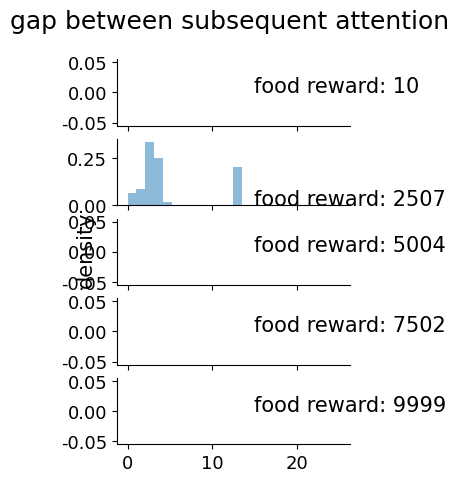

In [ ]:
# plot
fig, axs=plt.subplots(len(food_reward_list),1, figsize=(3,len(food_reward_list)), sharex=True)
for food_reward_idx in all_reward_res.keys():
    try:
        attention_prob_list,lick_prob_list,lick_time_list,att_time_list=all_reward_res[food_reward_idx]
        ax=axs[food_reward_idx]
        

        data=att_time_list

        v = find_gap(pad_zero_attention(data))
        # v = (v - min(v)) / (max(v) - min(v))
        # v = 1-v
        # sns.kdeplot(v, fill=False, bw_adjust=0.99,ax=ax)
        ax.text(15,0,f'food reward: {food_reward_list[food_reward_idx]:.0f}')
        ax.hist(v, alpha=0.5, bins=np.linspace(0,25,25), density= True)
    except Exception as e:
        print(e)
        continue
fig.text(0.02, 0.5, 'density', va='center', ha='center', rotation='vertical')
title = 'gap between subsequent attention' 
plt.suptitle(title)
# plt.legend()
plt.show()

In [ ]:
# for food_reward_idx in all_reward_res.keys():
#     attention_prob_list,lick_prob_list,lick_time_list,att_time_list=all_reward_res[food_reward_idx]
#     print(f'food reward: {food_reward_list[food_reward_idx]}')
#     try:
#         plot_over_episodes(att_time_list, title = 'attention time', plot_no_episodes = 100)
#     except Exception as e:
#         print(e)
#         print(f'bad food reward: {food_reward_list[food_reward_idx]}')
#         continue